In [84]:
%pip install catboost
%pip install xgboost
%pip install lightgbm


[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.1.1 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [104]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb
import lightgbm as lgb
import catboost as cb

sns.set_theme(style="whitegrid")

In [86]:
data = fetch_california_housing()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

print(X.head())
print()

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Размер обучающей выборки: {X_train.shape[0]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")
print(f"Размер тестовой выборки: {X_test.shape[0]}")

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  

Размер обучающей выборки: 12384
Размер валидационной выборки: 4128
Размер тестовой выборки: 4128


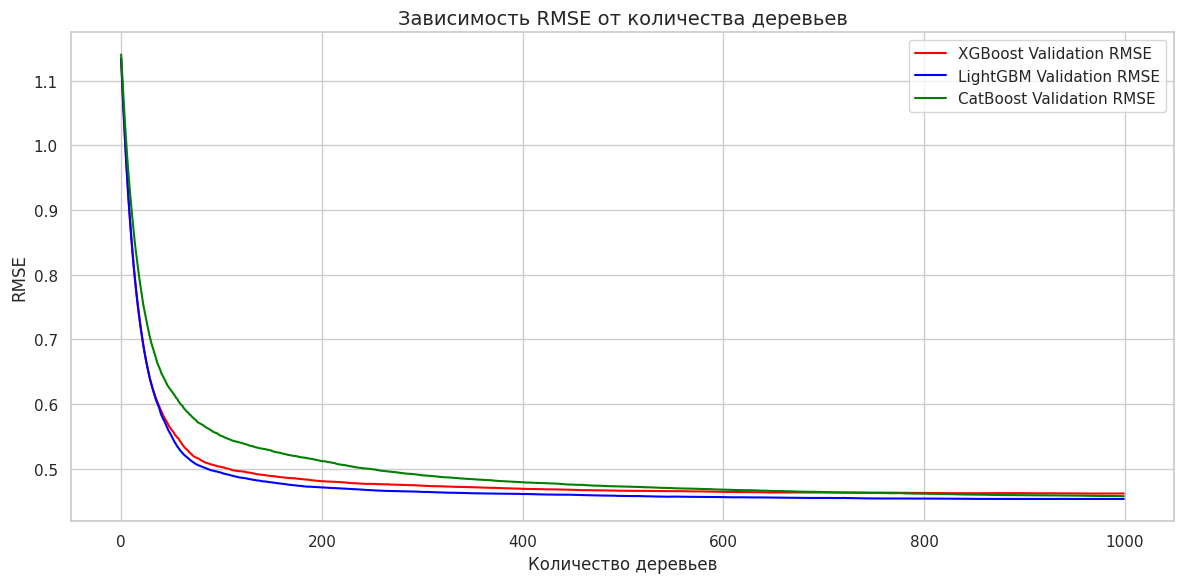

In [87]:
MAX_TREES = 1000
LEARNING_RATE = 0.05

xgb_model = xgb.XGBRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42)
xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
xgb_rmse = xgb_model.evals_result()['validation_0']['rmse']

lgb_model = lgb.LGBMRegressor(n_estimators=MAX_TREES, learning_rate=LEARNING_RATE, random_state=42, verbose=-1)
lgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], eval_metric='rmse')
lgb_metric_key = list(lgb_model.evals_result_['valid_0'].keys())[0]
lgb_rmse = lgb_model.evals_result_['valid_0'][lgb_metric_key]

cb_model = cb.CatBoostRegressor(iterations=MAX_TREES, learning_rate=LEARNING_RATE, eval_metric='RMSE', random_seed=42)
cb_model.fit(X_train, y_train, eval_set=(X_val, y_val), verbose=False)
cb_rmse = cb_model.evals_result_['learn']['RMSE']
cb_val_rmse = cb_model.evals_result_['validation']['RMSE']

plt.figure(figsize=(12, 6))
plt.plot(xgb_rmse, label='XGBoost Validation RMSE', color='red')
plt.plot(lgb_rmse, label='LightGBM Validation RMSE', color='blue')
plt.plot(cb_val_rmse, label='CatBoost Validation RMSE', color='green')

plt.title('Зависимость RMSE от количества деревьев', fontsize=14)
plt.xlabel('Количество деревьев', fontsize=12)
plt.ylabel('RMSE', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

In [88]:
SELECTED_N_ESTIMATORS = 400

In [120]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor

class MyBoost:
    def __init__(self, n=400, lr=0.05, depth=7, seed=42, subsample=0.8, colsample_bytree=0.8, cat_features=None) -> None:
        self.n = n
        self.lr = lr
        self.depth = depth
        self.seed = seed
        self.colsample_bytree = colsample_bytree
        self.subsample = subsample
        self.cat_features = cat_features if cat_features else []
        self.trees = []
        self.feature_importances_ = None
        self.cat_mappings = {}

    def _encode_categories(self, X, y=None, training=True):
        X_encoded = X.copy()
        
        for col in self.cat_features:
            if training:
                mapping = y.groupby(X[col]).mean()
                self.cat_mappings[col] = mapping
                X_encoded[col] = X[col].map(mapping).astype(float)
            else:
                mapping = self.cat_mappings[col]
                X_encoded[col] = X[col].map(mapping).fillna(self.initial_leaf).astype(float)
                
        return X_encoded

    def fit(self, X, y):
        if not isinstance(X, pd.DataFrame):
            X = pd.DataFrame(X)
        if not isinstance(y, pd.Series):
            y = pd.Series(y)

        self.initial_leaf = y.mean()
        
        X_encoded = self._encode_categories(X, y, training=True)

        n_rows, n_cols = X_encoded.shape
        row_size = int(n_rows * self.subsample)
        col_size = int(n_cols * self.colsample_bytree)

        self.feature_importances_ = np.zeros(n_cols)
        predictions = np.zeros(len(y)) + self.initial_leaf

        for i in range(self.n):
            np.random.seed(self.seed + i) 

            row_idx = np.random.choice(n_rows, size=row_size, replace=False)
            col_idx = np.random.choice(n_cols, size=col_size, replace=False)

            X_sampled = X_encoded.iloc[row_idx, col_idx]
            y_sampled = y.iloc[row_idx]
            
            antigrad = y_sampled - predictions[row_idx]

            tree = DecisionTreeRegressor(max_depth=self.depth, random_state=self.seed, criterion="friedman_mse")
            tree.fit(X_sampled, antigrad)
            
            self.trees.append((tree, col_idx))
            self.feature_importances_[col_idx] += tree.feature_importances_
            
            predictions += self.lr * tree.predict(X_encoded.iloc[:, col_idx])

        self.feature_importances_ /= self.n

    def predict(self, samples):
        if not isinstance(samples, pd.DataFrame):
            samples = pd.DataFrame(samples)
            
        samples_encoded = self._encode_categories(samples, training=False)
        
        predictions = np.zeros(len(samples)) + self.initial_leaf
        for tree, col_idx in self.trees:
            predictions += self.lr * tree.predict(samples_encoded.iloc[:, col_idx])

        return predictions

In [123]:
from sklearn.model_selection import ParameterGrid

X_train_full = pd.concat([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

grid_xgb = {
    'learning_rate': [0.05, 0.1],
    'max_depth':[5, 7],
    'subsample': [0.8, 1.0]
}

grid_lgb = {
    'learning_rate': [0.05, 0.1],
    'num_leaves': [31, 127],
    'subsample':[0.8, 1.0]
}

grid_cat = {
    'learning_rate':[0.05, 0.1],
    'depth': [5, 7],
    'subsample':[0.8, 1.0]
}

grid_skl = {
    'learning_rate': [0.05, 0.1],
    'max_depth': [5, 7],
    'subsample': [0.8, 1.0],
    'max_features': [0.8, 1.0]
}

def simple_grid_search(model_name, param_grid):
    print(f"--- Запуск Grid Search для {model_name} ---")
    best_rmse = float('inf')
    best_params = None

    start_time = time.time()

    for params in ParameterGrid(param_grid):
        if model_name == 'XGBoost':
            model = xgb.XGBRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1)
        elif model_name == 'LightGBM':
            model = lgb.LGBMRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1)
        elif model_name == 'sklearn':
            model = GradientBoostingRegressor(**params, n_estimators=SELECTED_N_ESTIMATORS, random_state=42, verbose=0)
        else:
            model = cb.CatBoostRegressor(**params, iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0)

        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        if rmse < best_rmse:
            best_rmse = rmse
            best_params = params

    total_time = time.time() - start_time
    print(f"Лучший Validation RMSE: {best_rmse:.4f}")
    print(f"Лучшие параметры: {best_params}\n")

    return best_params

best_params_dict = {}
best_params_dict['XGBoost'] = simple_grid_search('XGBoost', grid_xgb)
best_params_dict['LightGBM'] = simple_grid_search('LightGBM', grid_lgb)
best_params_dict['CatBoost'] = simple_grid_search('CatBoost', grid_cat)
best_params_dict['sklearn'] = simple_grid_search('sklearn', grid_skl)

--- Запуск Grid Search для XGBoost ---
Лучший Validation RMSE: 0.4621
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 7, 'subsample': 0.8}

--- Запуск Grid Search для LightGBM ---
Лучший Validation RMSE: 0.4557
Лучшие параметры: {'learning_rate': 0.1, 'num_leaves': 31, 'subsample': 0.8}

--- Запуск Grid Search для CatBoost ---
Лучший Validation RMSE: 0.4564
Лучшие параметры: {'depth': 7, 'learning_rate': 0.1, 'subsample': 1.0}

--- Запуск Grid Search для sklearn ---
Лучший Validation RMSE: 0.4608
Лучшие параметры: {'learning_rate': 0.1, 'max_depth': 7, 'max_features': 0.8, 'subsample': 1.0}



In [125]:
results = []

for name in ['MyBoost', 'LightGBM', 'CatBoost', 'XGBoost', 'sklearn']:
    params = best_params_dict.get(name, {}) # Берем пустой словарь, если параметров нет

    if name == 'XGBoost':
        model = xgb.XGBRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, **params)
    elif name == 'LightGBM':
        model = lgb.LGBMRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, n_jobs=-1, verbose=-1, **params)
    elif name == 'MyBoost':
        model = MyBoost(**params) 
    elif name == 'sklearn':
        model = GradientBoostingRegressor(n_estimators=SELECTED_N_ESTIMATORS, random_state=42, verbose=0, **params)
    else:
        model = cb.CatBoostRegressor(iterations=SELECTED_N_ESTIMATORS, random_seed=42, thread_count=-1, verbose=0, **params)

    start_time = time.time()
    model.fit(X_train_full, y_train_full)
    train_time = time.time() - start_time

    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "Время обучения": round(train_time, 3),
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "R2 Score": round(r2, 4)
    })

df_results = pd.DataFrame(results)
display(df_results)

,Модель,Время обучения,MAE,RMSE,R2 Score
0,MyBoost,38.608,0.2889,0.4413,0.8514
1,LightGBM,2.367,0.2862,0.4379,0.8537
2,CatBoost,2.129,0.2967,0.4493,0.8460
3,XGBoost,4.643,0.2912,0.4476,0.8471
4,sklearn,45.192,0.2885,0.4448,0.8490


In [126]:
styled_df = df_results.style.highlight_min(subset=['MAE', 'RMSE', 'Время обучения'], color='green') \
                            .highlight_max(subset=['R2 Score'], color='green') \
                            .highlight_max(subset=['MAE', 'RMSE', 'Время обучения'], color='red') \
                            .highlight_min(subset=['R2 Score'], color='red')

display(styled_df)

,Модель,Время обучения,MAE,RMSE,R2 Score
0,MyBoost,38.608000,0.288900,0.441300,0.851400
1,LightGBM,2.367000,0.286200,0.437900,0.853700
2,CatBoost,2.129000,0.296700,0.449300,0.846000
3,XGBoost,4.643000,0.291200,0.447600,0.847100
4,sklearn,45.192000,0.288500,0.444800,0.849000


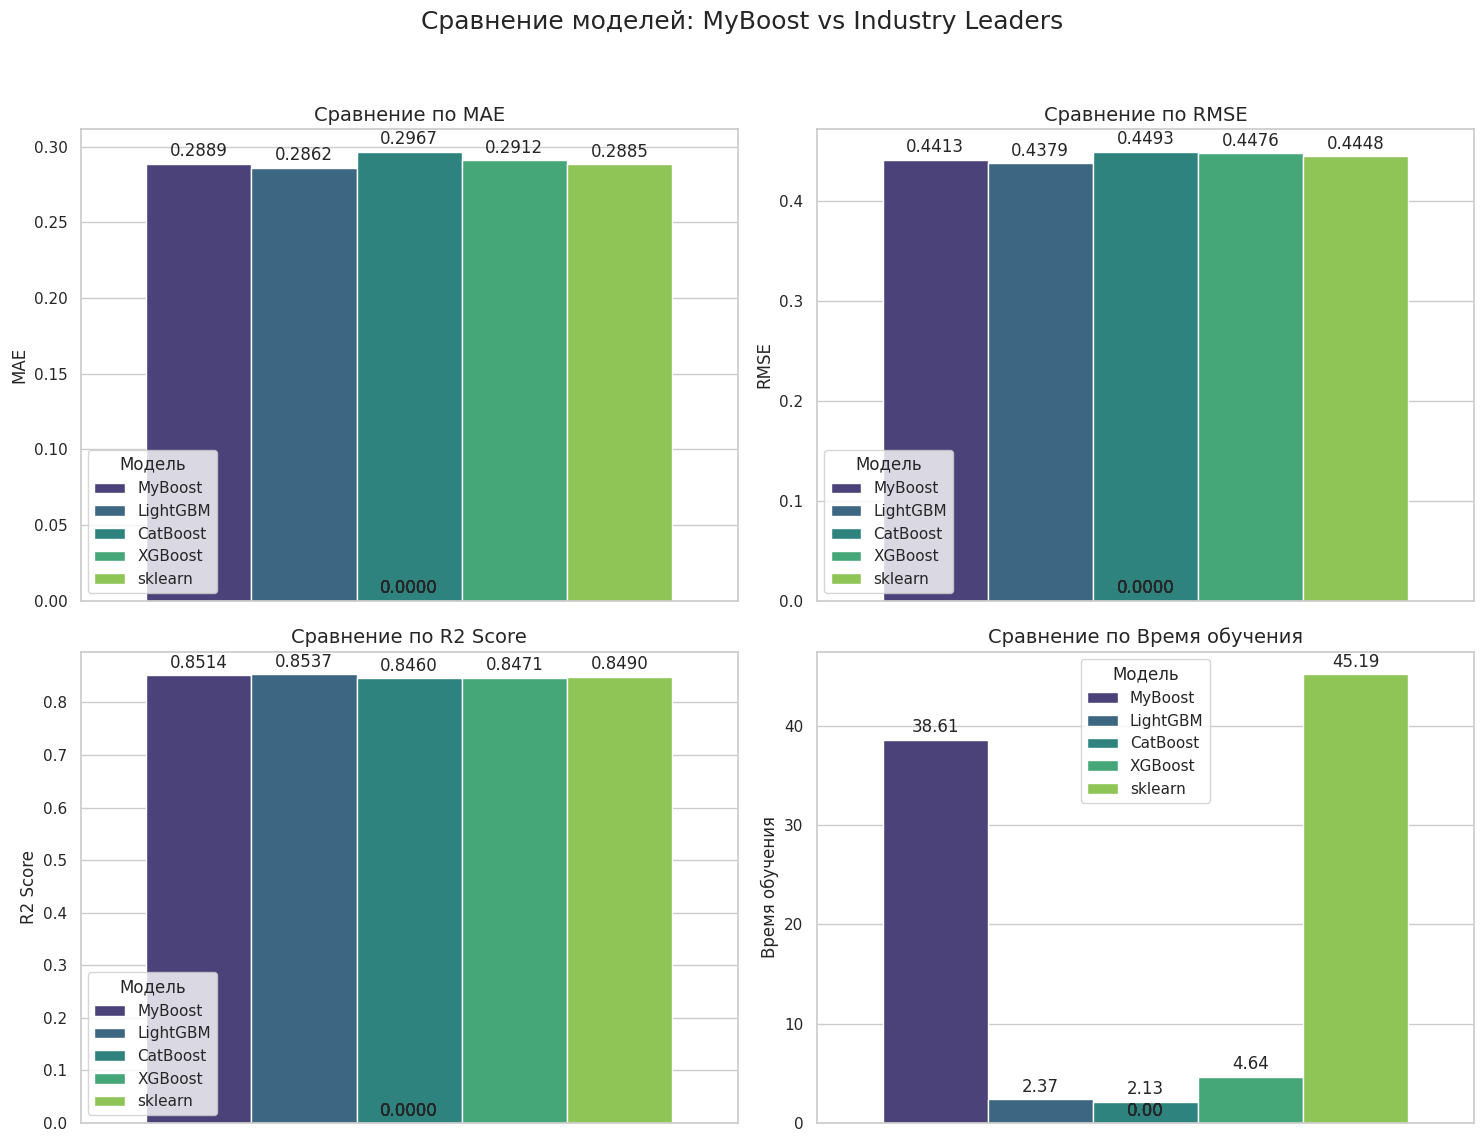

In [127]:
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Сравнение моделей: MyBoost vs Industry Leaders', fontsize=18)

metrics = ['MAE', 'RMSE', 'R2 Score', 'Время обучения']
palette = 'viridis'

for i, metric in enumerate(metrics):
    ax = axes[i//2, i%2]
    sns.barplot(data=df_results, hue='Модель', y=metric, ax=ax, palette=palette)
    ax.set_title(f'Сравнение по {metric}', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.4f' if metric != 'Время обучения' else '.2f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 9), 
                    textcoords = 'offset points')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

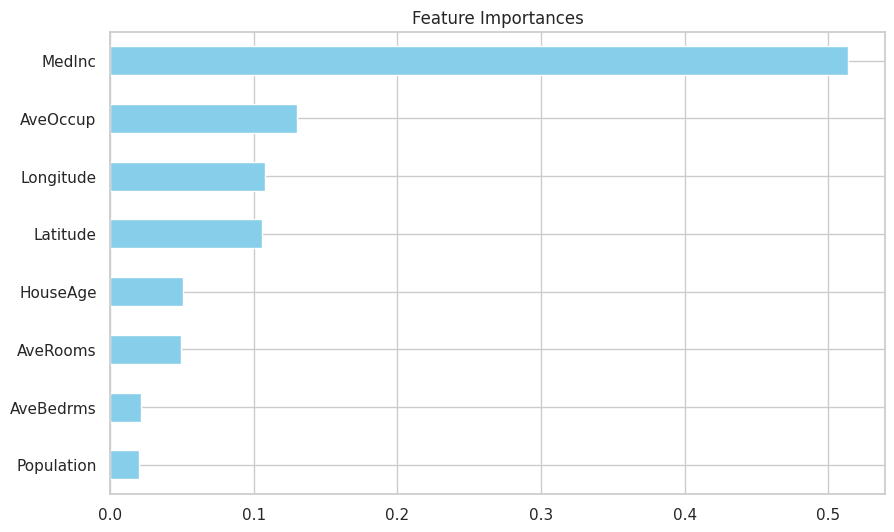

In [128]:
if 'MyBoost' in locals() or 'model' in locals():
    importances = df_results.loc[df_results['Модель'] == 'MyBoost']
    
    feat_imp = pd.Series(model.feature_importances_, index=X_train_full.columns)
    feat_imp = feat_imp.sort_values(ascending=False)

    plt.figure(figsize=(10, 6))
    feat_imp.plot(kind='barh', color='skyblue')
    plt.title('Feature Importances')
    plt.gca().invert_yaxis()
    plt.show()